# 01 — Data Exploration

This notebook performs the initial exploration of the scientific document dataset used in the project.

The project focuses on **Building a Knowledge Graph for Scientific Document Exploration using NLP and Semantic Retrieval**. Therefore, this notebook verifies that the selected arXiv metadata subset is suitable for downstream NLP tasks such as information extraction, semantic retrieval, and knowledge graph construction.

## Goals

- Load the project configuration and dataset.
- Inspect the arXiv metadata schema.
- Analyze category distribution.
- Analyze title, abstract, and combined document length.
- Save an exploration sample for later experiments.

In [2]:
from pathlib import Path
import sys

current = Path.cwd().resolve()

for candidate in [current, *current.parents]:
    if (candidate / "src").exists() and (candidate / "config.yaml").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find project root")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from src.utils.common import (
    display_basic_frame_info,
    load_project_documents,
    save_table,
    setup_notebook,
)

CONFIG, PATHS = setup_notebook()

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform
Config: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\config.yaml
Raw data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\raw
Processed data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed
Graphs: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\graphs
Figures: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports\figures


## Load dataset

In [4]:
df, documents, dataset_path = load_project_documents(CONFIG, PATHS)

print("Dataset file:", dataset_path)
print("Loaded documents:", len(documents))

display_basic_frame_info(df, "arXiv subset")

Dataset file: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\raw\arxiv-metadata-oai-snapshot.json
Loaded documents: 5000
arXiv subset shape: (5000, 6)
arXiv subset columns: ['doc_id', 'title', 'abstract', 'authors', 'categories', 'date']


,doc_id,title,abstract,authors,categories,date
0,1804.05499,Community Member Retrieval on Social Media usi...,This paper addresses the problem of communit...,"[Aaron Jaech, Shobhit Hathi, Mari Ostendorf]",[cs.CL],2018-04-17
1,2310.12815,Formalizing and Benchmarking Prompt Injection ...,A prompt injection attack aims to inject malic...,"[Yupei Liu, Yuqi Jia, Runpeng Geng, Jinyuan Ji...","[cs.CR, cs.AI, cs.CL, cs.LG]",2025-11-13
2,2303.12728,LocalEyenet: Deep Attention framework for Loca...,Development of human machine interface has b...,"[Somsukla Maiti, Akshansh Gupta]","[cs.CV, cs.LG]",2023-03-23
3,2012.12469,Augmenting Policy Learning with Routines Disco...,Humans can abstract prior knowledge from ver...,"[Zelin Zhao, Chuang Gan, Jiajun Wu, Xiaoxiao G...","[cs.LG, cs.AI, cs.SC]",2021-05-04
4,2601.10421,Are Language Models Models?,"Futrell and Mahowald claim LMs ""serve as model...",[Philip Resnik],"[cs.CL, cs.AI]",2026-01-16


## Validate expected schema

In [5]:
expected_columns = {"doc_id", "title", "abstract", "authors", "categories", "date"}
missing_columns = expected_columns.difference(df.columns)

if missing_columns:
    raise ValueError(f"Missing expected columns: {sorted(missing_columns)}")

print("Schema validation passed.")

Schema validation passed.


## Inspect dataset configuration

In [6]:
dataset_cfg = CONFIG.get("dataset", {})

print("Configured sample size:", dataset_cfg.get("sample_size"))
print("Configured categories:", dataset_cfg.get("categories"))
print("Random seed:", CONFIG.get("project", {}).get("seed", 42))

Configured sample size: 5000
Configured categories: ['cs.AI', 'cs.LG', 'cs.CL', 'cs.IR']
Random seed: 42


## Category distribution

In [7]:
from collections import Counter

category_counter = Counter()

for categories in df["categories"]:
    category_counter.update(categories)

category_df = (
    pd.DataFrame(category_counter.items(), columns=["category", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(category_df.head(25))

,category,count
0,cs.LG,3007
1,cs.AI,2091
2,cs.CL,1282
3,cs.CV,788
4,stat.ML,719
5,cs.IR,290
6,cs.CR,198
7,cs.RO,196
8,cs.HC,151
9,cs.CY,148


## Visualize top categories

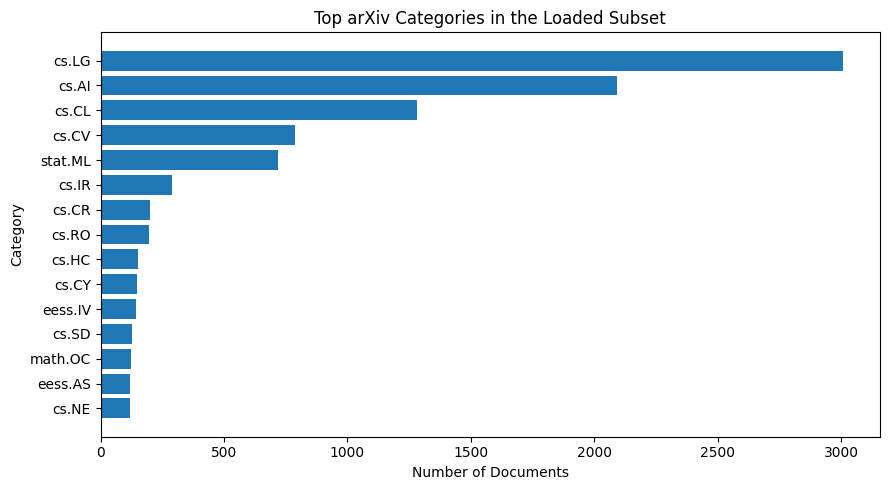

In [8]:
if category_df.empty:
    print("No categories available.")
else:
    top_categories = category_df.head(15).sort_values("count")

    plt.figure(figsize=(9, 5))
    plt.barh(top_categories["category"], top_categories["count"])
    plt.title("Top arXiv Categories in the Loaded Subset")
    plt.xlabel("Number of Documents")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()

## Text length analysis

In [9]:
df = df.copy()
df["title_word_count"] = df["title"].fillna("").astype(str).str.split().str.len()
df["abstract_word_count"] = df["abstract"].fillna("").astype(str).str.split().str.len()
df["combined_text"] = df["title"].fillna("").astype(str) + ". " + df["abstract"].fillna("").astype(str)
df["combined_word_count"] = df["combined_text"].str.split().str.len()

df[["title_word_count", "abstract_word_count", "combined_word_count"]].describe()

,title_word_count,abstract_word_count,combined_word_count
count,5000.000000,5000.000000,5000.000000
mean,9.708800,170.029000,179.737800
std,3.216407,47.688521,48.221067
min,1.000000,10.000000,12.000000
25%,8.000000,137.000000,146.750000
50%,9.000000,170.000000,179.000000
75%,12.000000,201.000000,211.000000
max,28.000000,441.000000,452.000000


## Visualize document length distribution

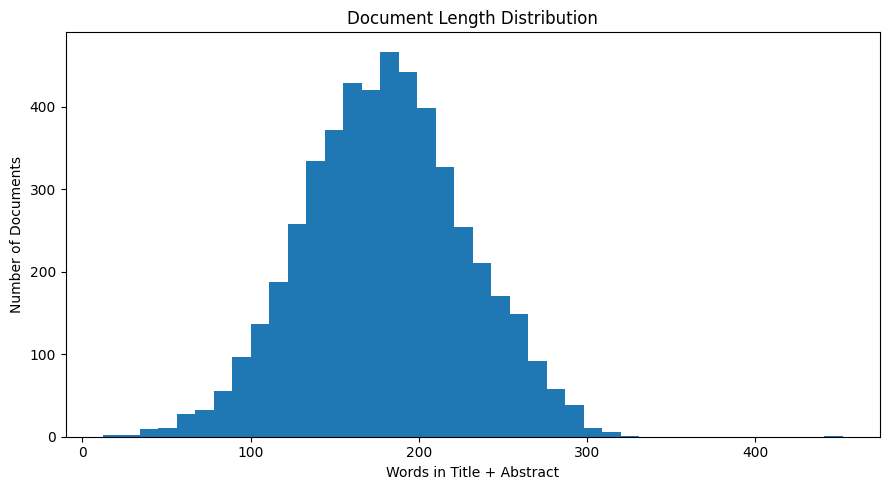

In [10]:
plt.figure(figsize=(9, 5))
plt.hist(df["combined_word_count"], bins=40)
plt.title("Document Length Distribution")
plt.xlabel("Words in Title + Abstract")
plt.ylabel("Number of Documents")
plt.tight_layout()
plt.show()

## Preview representative documents

In [11]:
preview_columns = ["doc_id", "title", "categories", "date", "abstract"]
display(df[preview_columns].head(5))

,doc_id,title,categories,date,abstract
0,1804.05499,Community Member Retrieval on Social Media usi...,[cs.CL],2018-04-17,This paper addresses the problem of communit...
1,2310.12815,Formalizing and Benchmarking Prompt Injection ...,"[cs.CR, cs.AI, cs.CL, cs.LG]",2025-11-13,A prompt injection attack aims to inject malic...
2,2303.12728,LocalEyenet: Deep Attention framework for Loca...,"[cs.CV, cs.LG]",2023-03-23,Development of human machine interface has b...
3,2012.12469,Augmenting Policy Learning with Routines Disco...,"[cs.LG, cs.AI, cs.SC]",2021-05-04,Humans can abstract prior knowledge from ver...
4,2601.10421,Are Language Models Models?,"[cs.CL, cs.AI]",2026-01-16,"Futrell and Mahowald claim LMs ""serve as model..."


## Save exploration sample

In [12]:
output_path = PATHS.data_processed / "exploration_sample.csv"
save_table(df, output_path)

print("Saved exploration sample to:", output_path)

Saved exploration sample to: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed\exploration_sample.csv
